# The Potential of N-body Simulations

galpy can set up and work with the frozen potential of an N-body simulation. This allows you to study the properties of such potentials, investigate orbits, and calculate action-angle coordinates using the galpy framework. Currently, this functionality uses axisymmetrized versions of the snapshots. The use of this functionality requires [pynbody](https://github.com/pynbody/pynbody).

In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
import numpy
from matplotlib import pyplot as plt
import pynbody
from galpy.potential import (
    SnapshotRZPotential,
    InterpSnapshotRZPotential,
    KeplerPotential,
)

## Simple example: SnapshotRZPotential

As a first, simple example we look at the potential of a single simulation particle, which should correspond to galpy's `KeplerPotential`. We can create such a single-particle snapshot using `pynbody` and then get its potential in galpy:

In [2]:
s = pynbody.new(star=1)
s["mass"] = 1.0
s["eps"] = 0.0
sp = SnapshotRZPotential(s, num_threads=1)

With these definitions, this snapshot potential should be the same as `KeplerPotential` with an amplitude of one, which we can verify:

In [3]:
from galpy.potential import KeplerPotential

kp = KeplerPotential(amp=1.0)
print("Potentials: ", sp(1.1, 0.0), kp(1.1, 0.0), sp(1.1, 0.0) - kp(1.1, 0.0))
print(
    "R forces: ",
    sp.Rforce(1.1, 0.0),
    kp.Rforce(1.1, 0.0),
    sp.Rforce(1.1, 0.0) - kp.Rforce(1.1, 0.0),
)

Potentials:  -0.9090909090909091 -0.9090909090909091 0.0
R forces:  -0.8264462809917354 -0.8264462809917353 -1.1102230246251565e-16


`SnapshotRZPotential` instances can be used wherever other galpy potentials can be used (note that the second derivatives have not been implemented, such that functions depending on those will not work). For example, we can plot the rotation curve:

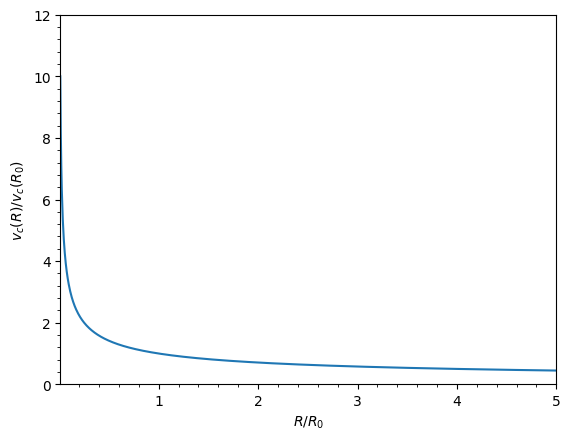

In [4]:
sp.plotRotcurve();

## InterpSnapshotRZPotential

Because evaluating the potential and forces of a snapshot is computationally expensive, most useful applications of frozen N-body potentials employ interpolated versions of the snapshot potential. These can be set up in galpy using `InterpSnapshotRZPotential`.

To illustrate its use we will make use of one of `pynbody`'s example snapshots, `g15784`. This snapshot is used in the [pynbody quickstart tutorial](https://pynbody.readthedocs.io/latest/tutorials/quickstart.html) and can be downloaded from [Zenodo](https://zenodo.org/records/12687409).

Once you have downloaded the testdata, load and prepare the snapshot:

In [5]:
s = pynbody.load("gasoline_ahf/g15784.lr.01024.gz")

# Get the main galaxy, center, and align face-on
h = s.halos()
h0 = h[0]
pynbody.analysis.faceon(h0)

# Convert to physical units with G=1
s.physical_units(mass="kpc km**2 s**-2 G**-1")

pynbody.halo : Unable to load AHF substructure file; continuing without. To expose the underlying problem as an exception, pass ignore_missing_substructure=False to the AHFCatalogue constructor


We can now load an interpolated version of this snapshot's potential into galpy:

In [6]:
spi = InterpSnapshotRZPotential(
    h0,
    rgrid=(numpy.log(0.01), numpy.log(20.0), 101),
    logR=True,
    zgrid=(0.0, 10.0, 101),
    interpPot=True,
    zsym=True,
)

where we further assume that the potential is symmetric around the mid-plane ($z=0$). Depending on the size of the simulation, this instantiation can take a long time. This potential instance has *physical* units (and thus the `rgrid=` and `zgrid=` inputs are given in kpc if the simulation's distance unit is kpc). For example, if we ask for the rotation curve:

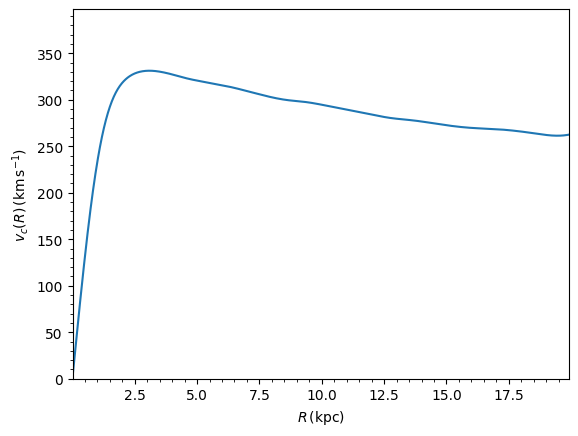

In [7]:
spi.plotRotcurve(
    Rrange=[0.01, 19.9],
    xlabel=r"$R\,(\mathrm{kpc})$",
    ylabel=r"$v_c(R)\,(\mathrm{km\,s}^{-1})$",
);

## Converting to natural units

Because galpy works best in a system of *natural units*, we can convert the interpolated snapshot potential to natural units using `normalize()`. For example, using the circular velocity at $R = 10$ kpc:

In [8]:
print("Vcirc at R=10 kpc:", spi.vcirc(10.0))
spi.normalize(R0=10.0)

Vcirc at R=10 kpc: 294.6732646339408


We can then plot the rotation curve again, keeping in mind that the distance unit is now $R_0$:

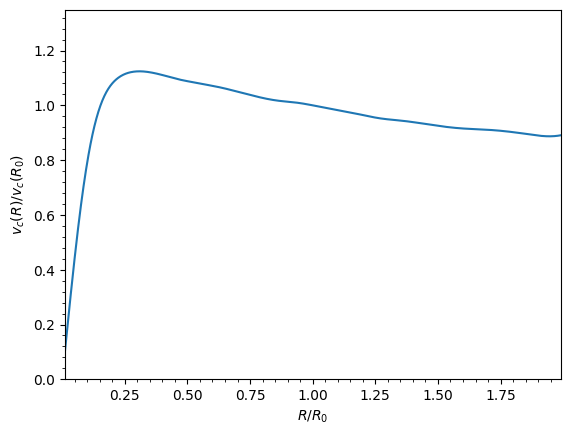

In [9]:
spi.plotRotcurve(Rrange=[0.01, 1.99])

In particular, `spi.vcirc(1.)` now returns `1.0`. We can also plot the potential:

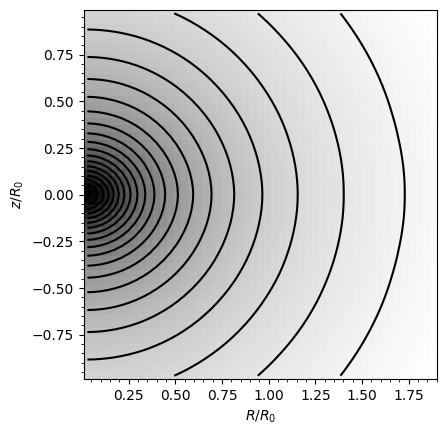

In [10]:
spi.plot(rmin=0.01, rmax=1.9, nrs=51, zmin=-0.99, zmax=0.99, nzs=51)
plt.gca().set_aspect(1.0);

This simulation's potential is quite spherical, which is confirmed by looking at the flattening:

In [11]:
print(f"Flattening at R=1.0, z=0.1: {spi.flattening(1.0, 0.1)}")
print(f"Flattening at R=1.5, z=0.1: {spi.flattening(1.5, 0.1)}")

Flattening at R=1.0, z=0.1: 0.8631229510097888
Flattening at R=1.5, z=0.1: 0.9430920419468051


The epicycle and vertical frequencies can also be interpolated by setting the `interpepifreq=True` or `interpverticalfreq=True` keywords when instantiating the `InterpSnapshotRZPotential` object.